In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
import ast as ast
import plotly.express as px
from IPython.display import display, HTML
from tqdm import tqdm
from chembl_webresource_client.new_client import new_client


def scrollable_html_table(df, max_rows, max_height="300px"):
    df_html = df.to_html(max_rows=max_rows)
    scrollable_html = f"""
    <div style="max-height: {max_height}; overflow: auto;">
        {df_html}
    </div>
    """
    display(HTML(scrollable_html))


blue = "#6C93D4"
dark_blue = "#3B6FC6"
green = "#79B794"
orange = "#F4A261"
red = "#C96480"
purple = "#9a7caa"
turquoise = "#7CDBEE"
pink = "#EA90D3"

In [ ]:
df_chembl_ids = pd.read_csv("data/extended_LAGOM_with_chembl36_ids.csv")
df_enriched = pd.read_csv("enriched_reactions.csv")

smiles = pd.concat([df_enriched["drug"], df_enriched["metabolite"]]).dropna().unique()
df_names = pd.DataFrame(smiles, columns=["smiles"])
df_names = df_names.drop_duplicates()

df_names = df_names.merge(
    df_chembl_ids[["smiles", "chembl_ids"]], on="smiles", how="left"
)
df_names["chembl_ids"] = df_names["chembl_ids"].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else []
)
df_names["pref_names"] = ""

# Get preferred names for each ChEMBL ID
molecule = new_client.molecule
for index, row in tqdm(df_names.iterrows(), total=df_names.shape[0]):
    smiles = row["smiles"]
    chembl_ids = row["chembl_ids"]

    pref_names = []
    for chembl_id in chembl_ids:
        try:
            mol_data = molecule.get(chembl_id)
            pref_name = mol_data.get("pref_name")
            pref_names.append(pref_name)
        except Exception:
            pref_names.append("N/A")

    df_names.at[index, "pref_names"] = str(pref_names)

# Go through preferred names and save the shortest name in list that is not None
for index, row in tqdm(df_names.iterrows(), total=df_names.shape[0]):
    pref_names = ast.literal_eval(row["pref_names"])
    shortest_name = None
    for name in pref_names:
        if name is not None and (
            shortest_name is None or len(name) < len(shortest_name)
        ):
            shortest_name = name
    df_names.at[index, "shortest_name"] = shortest_name

# For those that have no shortest name, fill in N/A
df_names["shortest_name"] = df_names["shortest_name"].fillna("N/A")


df_enriched = pd.read_csv("enriched_reactions.csv")
df_enriched = df_enriched.merge(
    df_names[["smiles", "shortest_name"]], left_on="drug", right_on="smiles", how="left"
)
df_enriched = df_enriched.rename(columns={"shortest_name": "drug_name"})
df_enriched = df_enriched.drop(columns=["smiles"])
df_enriched = df_enriched.merge(
    df_names[["smiles", "shortest_name"]],
    left_on="metabolite",
    right_on="smiles",
    how="left",
)
df_enriched = df_enriched.rename(columns={"shortest_name": "metabolite_name"})
df_enriched = df_enriched.drop(columns=["smiles"])

cols = df_enriched.columns.tolist()
cols.insert(cols.index("metabolite") + 1, cols.pop(cols.index("drug_name")))
cols.insert(cols.index("drug_name") + 1, cols.pop(cols.index("metabolite_name")))
df_enriched = df_enriched[cols]

df_enriched.to_csv("enriched_reactions.csv", index=False)

100%|██████████| 372/372 [00:00<00:00, 44716.16it/s]


Total enriched reactions: 849
[52.65017667844523, 3.651354534746761, 13.54534746760895, 30.153121319199055]


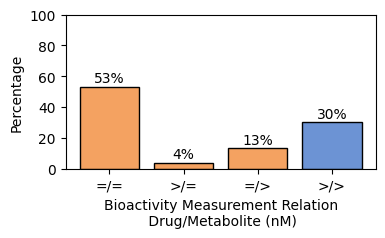

In [7]:
def histogram_relations(df):
    plt.figure(figsize=(4, 2))
    plt.rcParams["font.family"] = "sans-serif"

    relation_types = {
        "=/=": len(
            df[(df["relation_drug"] == "=") & (df["relation_metabolite"] == "=")]
        ),
        ">/=": len(
            df[(df["relation_drug"] == "<") & (df["relation_metabolite"] == "=")]
        ),
        "=/>": len(
            df[(df["relation_drug"] == "=") & (df["relation_metabolite"] == "<")]
        ),
        ">/>": len(
            df[(df["relation_drug"] == "<") & (df["relation_metabolite"] == "<")]
        ),
    }

    total = sum(relation_types.values())
    relation_types = {k: v / total * 100 for k, v in relation_types.items()}

    plt.bar(
        relation_types.keys(),
        relation_types.values(),
        color=[orange, orange, orange, blue],
        edgecolor="black",
    )
    plt.xlabel("Bioactivity Measurement Relation\n Drug/Metabolite (nM)", fontsize=10)
    plt.ylabel("Percentage", fontsize=10)
    plt.ylim(0, 100)

    values = list(relation_types.values())
    print(values)
    rounded = [53, 4, 13, 30]

    for i, v in enumerate(rounded):
        plt.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=10)

    plt.savefig("figures/histogram.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()


df = pd.read_csv("enriched_reactions.csv")
print(f"Total enriched reactions: {len(df)}")
histogram_relations(df)

In [8]:
df = pd.read_csv("enriched_reactions.csv")
len_start = len(df)
reaction_counts_start = df[["drug", "metabolite"]].value_counts()

df = df[
    ~((df["relation_drug"] == "<") & (df["relation_metabolite"] == "<"))
].reset_index(drop=True)
len_end = len(df)
reaction_counts_end = df[["drug", "metabolite"]].value_counts()
df_exact = df[((df["relation_drug"] == "=") & (df["relation_metabolite"] == "="))]
len_exact = len(df_exact)

# --- STATISTICS ---
print(f"Number of matched reactions: {len_start}")
print(f"Number of matched reactions with meaningful activity: {len_end}")

print("Number of unique reactions:", len(reaction_counts_start))
print("Number of unique reactions with meaningful activity:", len(reaction_counts_end))

Number of matched reactions: 849
Number of matched reactions with meaningful activity: 593
Number of unique reactions: 236
Number of unique reactions with meaningful activity: 211


Number of exact measurements: 447
lims: [5.0, 9.85]


/Users/kbvs588/Library/CloudStorage/OneDrive-AZCollaboration/Documents/bioactivity/Bioactivity/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


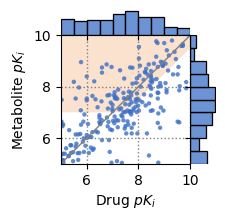

lims: [5.0, 10.22]


/Users/kbvs588/Library/CloudStorage/OneDrive-AZCollaboration/Documents/bioactivity/Bioactivity/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


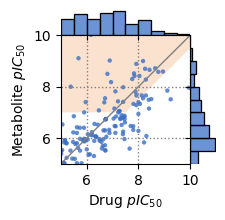

lims: [5.05, 9.74]


/Users/kbvs588/Library/CloudStorage/OneDrive-AZCollaboration/Documents/bioactivity/Bioactivity/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


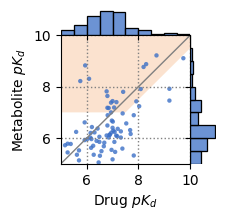

In [9]:
def plot_hist_and_scatter(
    name, df, Xr, Xp, Xrlabel, Xplabel, color_light="#3B6FC6", color_dark="#163A70"
):

    fontsize = 10
    height = 2
    limit = [5.0, 10.0]

    g = sns.JointGrid(data=df, x=Xr, y=Xp, height=height, space=0)
    plt.rcParams["font.family"] = "sans-serif"

    lims = [
        min(df[Xr].min(), df[Xp].min()),
        max(df[Xr].max(), df[Xp].max()),
    ]
    print(f"lims: {lims}")

    if limit is not None:
        lims = limit

    if "bioactivity" in Xr.lower():
        x = np.linspace(lims[0], lims[1], 500)
        x_intersect = 7.5
        y_lower = np.where(x <= x_intersect, 7, x - 0.5)
        y_upper = lims[1]

        g.ax_joint.fill_between(
            x,
            y_lower,
            y_upper,
            color=orange,
            alpha=0.3,
            linewidth=0,
            edgecolor=None,
            antialiased=True,
            zorder=1,
        )

    g.ax_joint.scatter(
        df[Xr], df[Xp], s=10, alpha=0.8, edgecolor="none", color=color_light
    )

    g.ax_joint.plot(lims, lims, ls="-", color="gray", lw=1, label="y = x")
    g.ax_joint.grid(True, which="both", linestyle=":", lw=1, color="gray")

    g.ax_joint.set_xlim(lims)
    g.ax_joint.set_ylim(lims)
    g.ax_joint.set_xlabel(Xrlabel, fontsize=fontsize)
    g.ax_joint.set_ylabel(Xplabel, fontsize=fontsize)
    g.ax_joint.tick_params(axis="both", which="major", labelsize=fontsize)

    sns.histplot(
        df[Xr],
        ax=g.ax_marg_x,
        color=color_light,
        bins=10,
        stat="density",
        binrange=lims,
    )
    sns.histplot(
        y=df[Xp],
        ax=g.ax_marg_y,
        color=color_light,
        bins=10,
        stat="density",
        binrange=lims,
    )

    plt.savefig(f"figures/{name}.svg", format="svg", bbox_inches="tight")
    plt.show()


df = pd.read_csv("enriched_reactions.csv")
df_len = len(df)
df = df[((df["relation_drug"] == "=") & (df["relation_metabolite"] == "="))]
print(f"Number of exact measurements: {len(df)}")
df_pki = df[df["bioactivity_type"] == "pKi"]
df_pic50 = df[df["bioactivity_type"] == "pIC50"]
df_pkd = df[df["bioactivity_type"] == "pKd"]

plot_hist_and_scatter(
    "pKi",
    df_pki,
    "bioactivity_drug",
    "bioactivity_metabolite",
    Xrlabel="Drug $pK_i$",
    Xplabel="Metabolite $pK_i$",
)
plot_hist_and_scatter(
    "pIC50",
    df_pic50,
    "bioactivity_drug",
    "bioactivity_metabolite",
    Xrlabel="Drug $pIC_{50}$",
    Xplabel="Metabolite $pIC_{50}$",
)
plot_hist_and_scatter(
    "pKd",
    df_pkd,
    "bioactivity_drug",
    "bioactivity_metabolite",
    Xrlabel="Drug $pK_d$",
    Xplabel="Metabolite $pK_d$",
)

In [ ]:
df = pd.read_csv("enriched_reactions.csv")
df = df[~((df["relation_drug"] == "<") & (df["relation_metabolite"] == "<"))]
len_start = len(df)
print("Total number of entries:", len_start)

df["diff"] = df["bioactivity_metabolite"] - df["bioactivity_drug"]
mask_positive = (
    (df["diff"] >= -0.5)
    & (df["relation_drug"] == "=")
    & (df["relation_metabolite"] == "=")
    & (df["bioactivity_metabolite"] >= 7.0)
)
mask_less_equal = (
    (df["relation_drug"] == "<")
    & (df["relation_metabolite"] == "=")
    & (df["bioactivity_metabolite"] >= 7.0)
)
df_retain = df[mask_positive | mask_less_equal]
df_non_active = df[~(mask_positive | mask_less_equal)]

df.loc[mask_positive | mask_less_equal, "subset"] = "DM+ set"
df.loc[~(mask_positive | mask_less_equal), "subset"] = "DM- set"
df = df.drop(columns=["diff"])
cols = df.columns.tolist()
cols.insert(cols.index("uniprot_id"), cols.pop(cols.index("chembl_id")))
df = df[cols]
df["metabolite_name"] = df["metabolite_name"].fillna("N/A")
df["drug_name"] = df["drug_name"].fillna("N/A")
df.to_csv("drug-metabolite_pairs.csv", index=False)

len_retain = len(df_retain)
print("Number of active entries:", len_retain)
print(
    f"Percentage of entries with active metabolites: {len_retain / len_start * 100:.0f}%"
)

df_retain_exact = df_retain[
    (df_retain["relation_drug"] == "=") & (df_retain["relation_metabolite"] == "=")
]
df_exact = df[(df["relation_drug"] == "=") & (df["relation_metabolite"] == "=")]
print(
    f"Number of exact measurements with active metabolites: {len(df_retain_exact)} out of {len(df_exact)}, {len(df_retain_exact) / len(df_exact) * 100:.0f}%"
)

df_retain = df_retain.drop(columns=["diff"])
df_non_active = df_non_active.drop(columns=["diff"])
df_retain.to_csv("drug-metabolite_pairs_active.csv", index=False)
df_non_active.to_csv("drug-metabolite_pairs_non_active.csv", index=False)

Total number of entries: 593
Number of active entries: 155
Percentage of entries with active metabolites: 26%
Number of exact measurements with active metabolites: 151 out of 447, 34%


In [ ]:
df = pd.read_csv("drug-metabolite_pairs.csv")
mask_above_7 = df["bioactivity_metabolite"] >= 7.0
df_met_active = df[mask_above_7]
len_met_active = len(df_met_active)
len_total = len(df)
print(
    f"Number of entries with metabolite bioactivity >= 7: {len_met_active} out of {len_total}, {len_met_active / len_total * 100:.0f}%"
)

Number of entries with metabolite bioactivity >= 7: 208 out of 593, 35%


In [14]:
# --- STATISTICS FOR BIOACTIVITY ---

df = pd.read_csv("drug-metabolite_pairs.csv")
df = df[((df["relation_drug"] == "=") & (df["relation_metabolite"] == "="))]
value_count = df["bioactivity_type"].value_counts()
print(value_count)

df = pd.read_csv("drug-metabolite_pairs_active.csv")
df = df[((df["relation_drug"] == "=") & (df["relation_metabolite"] == "="))]
value_count = df["bioactivity_type"].value_counts()
print(value_count)

bioactivity_type
pKi      229
pIC50    140
pKd       78
Name: count, dtype: int64
bioactivity_type
pKi      97
pIC50    36
pKd      18
Name: count, dtype: int64


Number of reactions in active set: 155
Number of reactions in non-active set: 438
lims: [-0.512, 4.628]
Adjusted lims: [-0.5632, 5.0908]


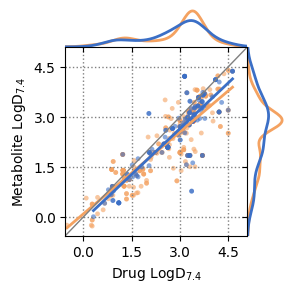

In [ ]:
def plot_hist_and_scatter(name, df_active, df_non_active, Xr, Xp, Xrlabel, Xplabel):

    fontsize = 10
    height = 3

    g = sns.JointGrid(data=df_active, x=Xr, y=Xp, height=height, space=0)
    plt.rcParams["font.family"] = "sans-serif"
    g.ax_joint.grid(True, which="both", linestyle=":", lw=1, color="gray")

    g.ax_joint.scatter(
        df_non_active[Xr],
        df_non_active[Xp],
        s=12,
        alpha=0.6,
        edgecolor="none",
        color=orange,
        marker="o",
        label="DM-",
    )
    g.ax_joint.scatter(
        df_active[Xr],
        df_active[Xp],
        s=12,
        alpha=0.6,
        edgecolor="none",
        color="#3B6FC6",
        marker="o",
        label="DM+",
    )

    sns.regplot(
        x=Xr,
        y=Xp,
        data=df_non_active,
        scatter=False,
        ax=g.ax_joint,
        color=orange,
        line_kws={"lw": 2, "ls": "-"},
        ci=None,
    )
    sns.regplot(
        x=Xr,
        y=Xp,
        data=df_active,
        scatter=False,
        ax=g.ax_joint,
        color="#3B6FC6",
        line_kws={"lw": 2, "ls": "-"},
        ci=None,
    )

    lims = [
        min(
            df_non_active[Xr].min(),
            df_non_active[Xp].min(),
            df_active[Xr].min(),
            df_active[Xp].min(),
        ),
        max(
            df_non_active[Xr].max(),
            df_non_active[Xp].max(),
            df_active[Xr].max(),
            df_active[Xp].max(),
        ),
    ]
    print(f"lims: {lims}")

    lims = [lims[0] - 0.1 * abs(lims[0]), lims[1] + 0.1 * abs(lims[1])]

    print(f"Adjusted lims: {lims}")

    g.ax_joint.plot(lims, lims, ls="-", color="gray", lw=1)

    g.ax_joint.set_xlim(lims)
    g.ax_joint.set_ylim(lims)
    g.ax_joint.set_xlabel(Xrlabel, fontsize=fontsize)
    g.ax_joint.set_ylabel(Xplabel, fontsize=fontsize)
    g.ax_joint.tick_params(axis="both", which="major", labelsize=fontsize)

    g.ax_joint.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
    g.ax_joint.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

    sns.kdeplot(df_non_active[Xr], ax=g.ax_marg_x, color=orange, lw=2, ls="-")
    sns.kdeplot(y=df_non_active[Xp], ax=g.ax_marg_y, color=orange, lw=2, ls="-")
    sns.kdeplot(df_active[Xr], ax=g.ax_marg_x, color="#3B6FC6", lw=2, ls="-")
    sns.kdeplot(y=df_active[Xp], ax=g.ax_marg_y, color="#3B6FC6", lw=2, ls="-")

    plt.savefig(f"figures/{name}.svg", format="svg", bbox_inches="tight")
    plt.show()


# --- LogD ---
df_active = pd.read_csv("drug-metabolite_pairs_active.csv")
print(f"Number of reactions in active set: {len(df_active)}")
df_non_active = pd.read_csv("drug-metabolite_pairs_non_active.csv")
print(f"Number of reactions in non-active set: {len(df_non_active)}")

plot_hist_and_scatter(
    "logD",
    df_active,
    df_non_active,
    "logd_drug",
    "logd_metabolite",
    Xrlabel="Drug LogD$_{7.4}$",
    Xplabel="Metabolite LogD$_{7.4}$",
)

lims: [-1.04, 6.45]
Adjusted lims: [-1.1440000000000001, 7.095000000000001]


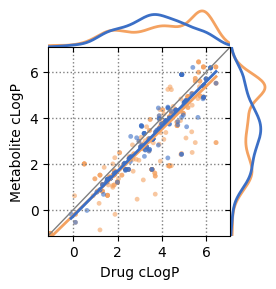

In [16]:
# --- cLogP ---
df_active = pd.read_csv("drug-metabolite_pairs_active.csv")
df_non_active = pd.read_csv("drug-metabolite_pairs_non_active.csv")

plot_hist_and_scatter(
    "cLogP",
    df_active,
    df_non_active,
    "logp_drug",
    "logp_metabolite",
    Xrlabel="Drug cLogP",
    Xplabel="Metabolite cLogP",
)

lims: [3.24, 204.66]
Adjusted lims: [2.9160000000000004, 225.126]


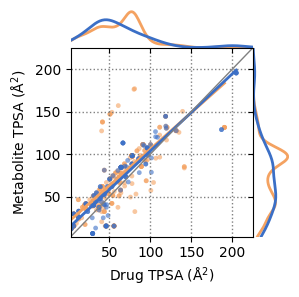

Average TPSA difference (metabolite - drug) in whole set (593): 10.3
Average TPSA difference (metabolite - drug) in active set (155): 7.3
Average TPSA difference (metabolite - drug) in non-active set (438): 11.4


In [17]:
# --- TPSA ---
df_active = pd.read_csv("drug-metabolite_pairs_active.csv")
df_non_active = pd.read_csv("drug-metabolite_pairs_non_active.csv")

plot_hist_and_scatter(
    "tpsa",
    df_active,
    df_non_active,
    "tpsa_drug",
    "tpsa_metabolite",
    Xrlabel="Drug TPSA (Å$^2$)",
    Xplabel="Metabolite TPSA (Å$^2$)",
)

# Get average difference in TPSA between drug and metabolite in active set
df = pd.read_csv("drug-metabolite_pairs.csv")
df["tpsa_diff"] = df["tpsa_metabolite"] - df["tpsa_drug"]
avg_tpsa_diff = df["tpsa_diff"].mean()
print(
    f"Average TPSA difference (metabolite - drug) in whole set ({len(df)}): {avg_tpsa_diff:.1f}"
)

df_active["tpsa_diff"] = df_active["tpsa_metabolite"] - df_active["tpsa_drug"]
avg_tpsa_diff = df_active["tpsa_diff"].mean()
print(
    f"Average TPSA difference (metabolite - drug) in active set ({len(df_active)}): {avg_tpsa_diff:.1f}"
)

df_non_active["tpsa_diff"] = (
    df_non_active["tpsa_metabolite"] - df_non_active["tpsa_drug"]
)
avg_tpsa_diff_non_active = df_non_active["tpsa_diff"].mean()
print(
    f"Average TPSA difference (metabolite - drug) in non-active set ({len(df_non_active)}): {avg_tpsa_diff_non_active:.1f}"
)

lims: [-0.047, 2.513]
Adjusted lims: [-0.0517, 2.7643]


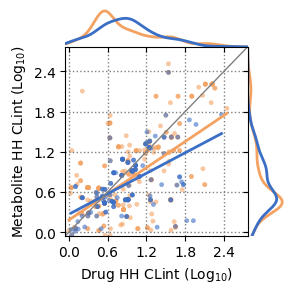

In [18]:
hh = pd.read_csv(r"../results_clearance.csv")

df_active = pd.read_csv("drug-metabolite_pairs_active.csv")
df_hh_active = df_active.merge(
    hh, left_on=["drug", "metabolite"], right_on=["drug", "metabolite"], how="inner"
)
df_non_active = pd.read_csv("drug-metabolite_pairs_non_active.csv")
df_hh_non_active = df_non_active.merge(
    hh, left_on=["drug", "metabolite"], right_on=["drug", "metabolite"], how="inner"
)

plot_hist_and_scatter(
    "hh",
    df_hh_active,
    df_hh_non_active,
    "hh_drug",
    "hh_metabolite",
    Xrlabel="Drug HH CLint (Log$_{10}$)",
    Xplabel="Metabolite HH CLint (Log$_{10}$)",
)

In [19]:
def print_statistics(df_active, df_non_active, df, column, spec):

    count_active = df_active[df_active[column] == spec]
    count_non_active = df_non_active[df_non_active[column] == spec]
    count_df = df[df[column] == spec]

    print(
        f"& {len(count_active)} \t\t& {len(count_active) / len(count_df) * 100:.1f} \t\t& {len(count_non_active)} \t\t& {len(count_non_active) / len(count_df) * 100:.1f} \t \\\\ % {spec}"
    )

df = pd.read_csv("drug-metabolite_pairs.csv")
df_active = pd.read_csv("drug-metabolite_pairs_active.csv")
df_non_active = pd.read_csv("drug-metabolite_pairs_non_active.csv")

template_count = df["template r=0"].value_counts()
template_count_active = df_active["template r=0"].value_counts()
template_count_non_active = df_non_active["template r=0"].value_counts()

print(template_count_active.head(10))
print("---")
print(template_count_non_active.head(5))
print("\n")

print(len(df))
print(f"{len(df_active)}, {len(df_active) / len(df) * 100:.1f}")
print(f"{len(df_non_active)}, {len(df_non_active) / len(df) * 100:.1f}")

print("#Active \t %Active  \t #Non-active \t %Non-active ")
print("Active:")
print_statistics(
    df_active, df_non_active, df, "template r=0", "C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "C-[N;H0;D3;+0:1]>>[NH;D2;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "[CH2;D2;+0:1]>>[CH;D3;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "[cH;D2;+0:1]>>[c;H0;D3;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "[O-]-[S+;H0;D3:1]>>[S;H0;D2;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "O-C-C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "[OH;D1;+0:1]>>[O;H0;D2;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "[CH3;D1;+0:1]>>[CH2;D2;+0:1]"
)
print_statistics(
    df_active, df_non_active, df, "template r=0", "C-[NH;D2;+0:1]>>[NH2;D1;+0:1]"
)
print_statistics(
    df_active,
    df_non_active,
    df,
    "template r=0",
    "[C;H0;D3;+0:1]=[O;H0;D1;+0:2]>>[CH;D3;+0:1]-[OH;D1;+0:2]",
)


template r=0
C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]                              26
C-[N;H0;D3;+0:1]>>[NH;D2;+0:1]                              22
[CH2;D2;+0:1]>>[CH;D3;+0:1]                                 19
[O-]-[S+;H0;D3:1]>>[S;H0;D2;+0:1]                            6
[cH;D2;+0:1]>>[c;H0;D3;+0:1]                                 6
[CH3;D1;+0:1]>>[CH2;D2;+0:1]                                 4
[OH;D1;+0:1]>>[O;H0;D2;+0:1]                                 4
C-C-[NH;D2;+0:1]>>[NH2;D1;+0:1]                              4
[C;H0;D3;+0:1]=[O;H0;D1;+0:2]>>[CH;D3;+0:1]-[OH;D1;+0:2]     4
O-C-C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]                           4
Name: count, dtype: int64
---
template r=0
[CH2;D2;+0:1]>>[CH;D3;+0:1]       140
C-[N;H0;D3;+0:1]>>[NH;D2;+0:1]     29
C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]     28
C-[NH;D2;+0:1]>>[NH2;D1;+0:1]      28
[cH;D2;+0:1]>>[c;H0;D3;+0:1]       18
Name: count, dtype: int64


593
155, 26.1
438, 73.9
#Active 	 %Active  	 #Non-active 	 %Non-active 
Active:
& 26 		& 48.1 		

In [20]:
def sunburst_targets(df, name, set_level):

    df["target_list"] = df["target_classification"].apply(
        lambda x: x.split("  ") if isinstance(x, str) else []
    )
    max_levels = df["target_list"].apply(len).max()
    print(f"Max levels in target classification: {max_levels}")

    # Create level columns and pad with dummy
    for index, row in df.iterrows():
        levels = len(row["target_list"])
        for level in range(levels):
            col_name = f"level_{level + 1}"
            if col_name not in df.columns:
                df[col_name] = None
            df.at[index, col_name] = row["target_list"][level]

    desired_order = [
        "enzyme",
        "membrane receptor",
        "transporter",
        "ion channel",
        "transcription factor",
    ]
    df["level_1_order"] = df["level_1"].apply(
        lambda x: desired_order.index(x) if x in desired_order else len(desired_order)
    )
    df = df.sort_values("level_1_order").reset_index(drop=True)
    df = df.drop("level_1_order", axis=1)

    # Identify leaf nodes
    data = df["target_list"].tolist()
    paths = [tuple(x for x in row if x is not None) for row in data]
    internal_nodes = set()
    for p in paths:
        for i in range(1, len(p)):
            internal_nodes.add(p[:i])
    is_leaf = [p not in internal_nodes for p in paths]
    print(f"Number of leaf nodes: {sum(is_leaf)} out of {len(is_leaf)} total nodes.")

    # If not leaf, replace next level with 'unclassified'
    for i, leaf in enumerate(is_leaf):
        if not leaf:
            levels = len(df.iloc[i]["target_list"])
            for level in range(levels, max_levels):
                col_name = f"level_{level + 1}"
                df.at[i, col_name] = "unclassified"
                break

    df_levels = df[[f"level_{i + 1}" for i in range(set_level)]]
    print(df_levels.columns)

    # Rename small categories to 'rest'
    if name == "other" or name == "all":
        thresholds = {1: 10}

        for level in range(1, len(df_levels.columns) + 1):
            col_name = f"level_{level}"
            if col_name not in df_levels.columns:
                continue

            threshold = thresholds.get(
                level, 0
            )  # 0 means no filtering for other levels

            if threshold > 0:
                # Count occurrences at this level
                value_counts = df_levels[col_name].value_counts()
                small_categories = value_counts[value_counts < threshold].index.tolist()

                # For each row, if this level is a small category, rename it and all subsequent levels to 'rest'
                for idx in df_levels.index:
                    if df_levels.at[idx, col_name] in small_categories:
                        # Rename this level and all subsequent levels to 'rest'
                        for subsequent_level in range(
                            level, len(df_levels.columns) + 1
                        ):
                            subsequent_col = f"level_{subsequent_level}"
                            if (
                                subsequent_col in df_levels.columns
                                and df_levels.at[idx, subsequent_col] is not None
                            ):
                                df_levels.at[idx, subsequent_col] = "rest"

    # Get only rows with enzyme in level_1
    if set_level == 2:
        df_levels = df_levels[df_levels["level_1"] == "enzyme"].reset_index(drop=True)

        desired_order = [
            "kinase",
            "lyase",
            "cytochrome p450",
            "reductase",
            "hydrolase",
            "protease",
            "transferase",
            "unclassified",
            "isomerase",
        ]
        df_levels["level_2_order"] = df_levels["level_2"].apply(
            lambda x: (
                desired_order.index(x) if x in desired_order else len(desired_order)
            )
        )
        df_levels = df_levels.sort_values("level_2_order").reset_index(drop=True)
        df_levels = df_levels.drop("level_2_order", axis=1)

    names = []
    parents = []
    labels = []
    seen_nodes = set()
    counts = {}

    for _, row in df_levels.iterrows():
        path = [x for x in row if x is not None]  # Ignore Nones
        for i in range(len(path)):
            # Create unique id for each node (full path up to this node)
            node_id = "/".join(path[: i + 1])
            parent_id = "" if i == 0 else "/".join(path[:i])
            label_id = path[i]
            counts[node_id] = counts.get(node_id, 0) + 1

            if node_id not in seen_nodes:
                names.append(node_id)
                parents.append(parent_id)
                labels.append(label_id)
                seen_nodes.add(node_id)

    values = [counts[name] for name in names]

    print("names:", names)
    print("labels:", labels)
    print("parents:", parents)
    print("values:", values)

    # MANUALLY CHANGE FOR FORMATTING
    if name == "active" and set_level == 1:
        size = 300
        rotation = "radial"
        seq = [
            blue,
            orange,
            green,
            red,
            purple,
            pink,
            # turquoise
        ]
        # ['enzyme', 'membrane receptor', 'transporter', 'ion channel', 'transcription factor', 'secreted']
        labels = [
            "Enzyme",
            "Membrane<br>receptor",
            "Transporter",
            "Ion channel",
            "Transcription factor",
            "Secreted",
        ]

    if name == "active_enz" and set_level == 2:
        size = 150
        rotation = "auto"
        seq = [blue]

        # ['enzyme', 'kinase', 'lyase', 'cytochrome p450', 'reductase', 'hydrolase', 'protease', 'transferase', 'unclassified', 'isomerase', 'ligase']
        labels = ["Enzyme", "Kinase", "Lyase", "CYPs", "", "", "", "", "", "", ""]

    if name == "other" and set_level == 1:
        size = 300
        rotation = "auto"
        seq = [
            blue,
            orange,
            green,
            red,
            purple,
            # pink,
            turquoise,
        ]
        # ['enzyme', 'membrane receptor', 'transporter', 'ion channel', 'transcription factor', 'rest']
        labels = [
            "Enzyme",
            "Membrane<br>receptor",
            "Transporter",
            "Ion channel",
            "Transcription factor",
            "Other",
        ]

    if name == "other_enz" and set_level == 2:
        size = 150
        rotation = "auto"
        seq = [blue]
        # ['enzyme', 'kinase', 'lyase', 'cytochrome p450', 'reductase', 'hydrolase', 'protease', 'unclassified', 'isomerase', 'transferase', 'phosphodiesterase']
        labels = ["Enzyme", "Kinase", "Lyase", "CYPs", "", "", "", "", "", "", ""]

    fig = px.sunburst(
        ids=names,
        names=labels,
        parents=parents,
        values=values,
        color=None,
        color_discrete_sequence=seq,
    )

    fig.update_traces(
        branchvalues="total",
        sort=False,
        insidetextorientation=rotation,
        textfont=dict(color="black", size=14, family="sans-serif"),
        leaf=dict(opacity=1),
    )
    fig.update_layout(margin=dict(t=10, l=10, r=10, b=10))
    fig.update_layout(width=size, height=size)

    fig.write_image(
        f"figures/sunburst_{name}.svg", format="svg", width=size, height=size
    )

    fig.show()


df = pd.read_csv("drug-metabolite_pairs_active.csv")
sunburst_targets(df, "active", 1)
sunburst_targets(df, "active_enz", 2)
df = pd.read_csv("drug-metabolite_pairs_non_active.csv")
sunburst_targets(df, "other", 1)
sunburst_targets(df, "other_enz", 2)

Max levels in target classification: 6
Number of leaf nodes: 151 out of 155 total nodes.
Index(['level_1'], dtype='object')
names: ['enzyme', 'membrane receptor', 'transporter', 'ion channel', 'transcription factor', 'secreted']
labels: ['enzyme', 'membrane receptor', 'transporter', 'ion channel', 'transcription factor', 'secreted']
parents: ['', '', '', '', '', '']
values: [45, 82, 11, 6, 5, 6]


Max levels in target classification: 6
Number of leaf nodes: 151 out of 155 total nodes.
Index(['level_1', 'level_2'], dtype='object')
names: ['enzyme', 'enzyme/kinase', 'enzyme/lyase', 'enzyme/cytochrome p450', 'enzyme/reductase', 'enzyme/hydrolase', 'enzyme/protease', 'enzyme/transferase', 'enzyme/unclassified', 'enzyme/isomerase', 'enzyme/ligase']
labels: ['enzyme', 'kinase', 'lyase', 'cytochrome p450', 'reductase', 'hydrolase', 'protease', 'transferase', 'unclassified', 'isomerase', 'ligase']
parents: ['', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme']
values: [45, 25, 7, 4, 1, 1, 1, 3, 1, 1, 1]


Max levels in target classification: 6
Number of leaf nodes: 419 out of 438 total nodes.
Index(['level_1'], dtype='object')
names: ['enzyme', 'membrane receptor', 'transporter', 'ion channel', 'transcription factor', 'rest']
labels: ['enzyme', 'membrane receptor', 'transporter', 'ion channel', 'transcription factor', 'rest']
parents: ['', '', '', '', '', '']
values: [229, 102, 49, 14, 22, 22]


Max levels in target classification: 6
Number of leaf nodes: 419 out of 438 total nodes.
Index(['level_1', 'level_2'], dtype='object')
names: ['enzyme', 'enzyme/kinase', 'enzyme/lyase', 'enzyme/cytochrome p450', 'enzyme/reductase', 'enzyme/hydrolase', 'enzyme/protease', 'enzyme/transferase', 'enzyme/unclassified', 'enzyme/isomerase', 'enzyme/phosphodiesterase']
labels: ['enzyme', 'kinase', 'lyase', 'cytochrome p450', 'reductase', 'hydrolase', 'protease', 'transferase', 'unclassified', 'isomerase', 'phosphodiesterase']
parents: ['', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme']
values: [229, 147, 32, 19, 17, 4, 3, 1, 4, 1, 1]


In [ ]:
def draw_reaction(df, index):

    row = df.iloc[index]
    reactant_smiles = row["drug"]
    product_smiles = row["metabolite"]

    name_drug = row["drug_name"]
    name_metabolite = row["metabolite_name"]

    reactant_mol = Chem.MolFromSmiles(reactant_smiles)
    product_mol = Chem.MolFromSmiles(product_smiles)

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    for ax, mol in zip(axes, [reactant_mol, product_mol]):
        img = Chem.Draw.MolToImage(mol, size=(300, 300))
        ax.imshow(img)
        ax.axis("off")

    axes[0].set_title(f"Drug: {name_drug}", fontsize=12)
    axes[1].set_title(f"Metabolite: {name_metabolite}", fontsize=12)

    plt.tight_layout()
    plt.show()


def plot_reaction(df, template):

    df = df.drop_duplicates(subset=["drug", "metabolite"]).reset_index(drop=True)

    subset = df[df["template r=0"] == template].reset_index(drop=True)
    print(f"Number of reactions for template {template}: {len(subset)}")

    if len(subset) == 0:
        print("No reactions found for this template.")
        return
    else:
        max = len(subset)

    for index in range(min(len(subset), max)):
        draw_reaction(subset, index)

df = pd.read_csv("drug-metabolite_pairs_non_active.csv")

# o-demethylation
# plot_reaction(df, 'C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]')
# n-demethylation (tert)
# plot_reaction(df, 'C-[N;H0;D3;+0:1]>>[NH;D2;+0:1]')
# hydroxylation (aliphatic ring)
# plot_reaction(df, '[CH2;D2;+0:1]>>[CH;D3;+0:1]')
# hydroxylation (aromatic)
# plot_reaction(df, '[cH;D2;+0:1]>>[c;H0;D3;+0:1]')
# deoxygenation (s)
# plot_reaction(df, '[O-]-[S+;H0;D3:1]>>[S;H0;D2;+0:1]')
# o-dealkylation
# plot_reaction(df, 'O-C-C-[O;H0;D2;+0:1]>>[OH;D1;+0:1]')
# conjugation
# plot_reaction(df, '[OH;D1;+0:1]>>[O;H0;D2;+0:1]')
# hydroxylation (aliphatic chain)
# plot_reaction(df, '[CH3;D1;+0:1]>>[CH2;D2;+0:1]')
# n-demethylation (sec)
# plot_reaction(df, 'C-[NH;D2;+0:1]>>[NH2;D1;+0:1]')
# oxidation
# plot_reaction(df, '[C;H0;D3;+0:1]=[O;H0;D1;+0:2]>>[CH;D3;+0:1]-[OH;D1;+0:2]')
